# Audio Classification Model Evaluation

This notebook evaluates the trained CNN on the held-out test dataset.

The notebook reports:

- Test accuracy
- Precision, recall, and F1-score
- Confusion matrix
- Example model predictions

These results are used in the README Results section.

In [20]:
# Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Added to sys.path:", str(PROJECT_ROOT) in sys.path)

TEST_DIR = PROJECT_ROOT / "data" / "data_split" / "test"

import os
print(TEST_DIR.exists())
print(TEST_DIR)

from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from audio_classification.models.cnn import SpectrogramCNN
from audio_classification.data.dataset import SpectrogramDataset

Project root: /Users/jurnee/Desktop/STEM EDUCATION/DSCI 410L/audio-classification-project
Added to sys.path: True
True
/Users/jurnee/Desktop/STEM EDUCATION/DSCI 410L/audio-classification-project/data/data_split/test


In [9]:
# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


## Load Test Dataset

In [10]:
test_dataset = SpectrogramDataset(root_dir=TEST_DIR)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test samples:", len(test_dataset))

Test samples: 186


## Check Class Mapping

In [11]:
try:
    print("Class mapping:", test_dataset.class_to_idx)
except:
    print("No class_to_idx attribute found in dataset class.")

Class mapping: {'Bass': 0, 'Hi Hat': 1, 'Kick': 2, 'Pad': 3, 'Snare': 4, 'Vocal': 5}


## Load Best Model

In [12]:
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "best_model.pth"

model = SpectrogramCNN(num_classes=6).to(DEVICE)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Best model loaded.")
print("Best epoch:", checkpoint["epoch"])
print("Validation accuracy:", checkpoint["val_acc"])

Best model loaded.
Best epoch: 9
Validation accuracy: 0.9560439560439561


## Generate Predictions

In [13]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

## Test Accuracy

In [14]:
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9247


## Classification Report

In [15]:
class_names = list(
    test_dataset.class_to_idx.keys()
)

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

        Bass       0.89      0.86      0.88        29
      Hi Hat       0.89      0.96      0.93        26
        Kick       0.97      0.97      0.97        36
         Pad       0.88      1.00      0.94        30
       Snare       0.95      0.93      0.94        40
       Vocal       0.95      0.80      0.87        25

    accuracy                           0.92       186
   macro avg       0.92      0.92      0.92       186
weighted avg       0.93      0.92      0.92       186



## Confusion Matrix

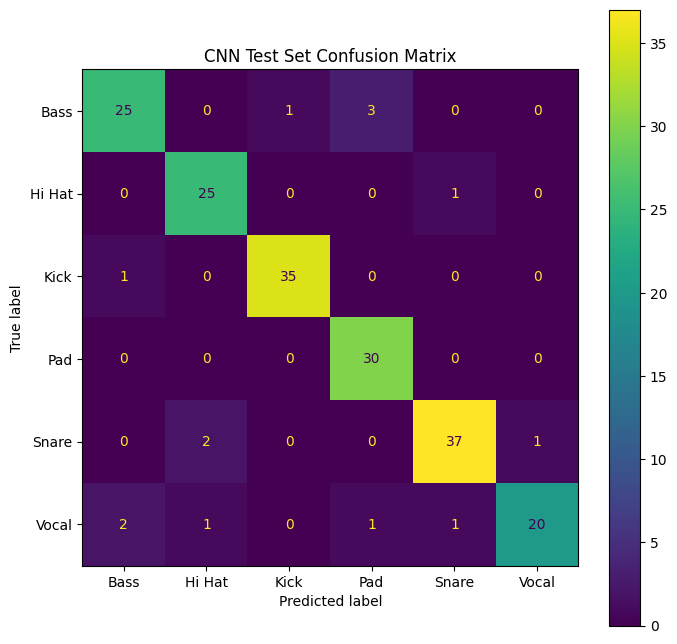

In [16]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

fig, ax = plt.subplots(
    figsize=(8,8)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(ax=ax)

plt.title("CNN Test Set Confusion Matrix")
plt.savefig('../outputs/plots/eval_confusion_matrix.png')
plt.show()

## Example Predictions

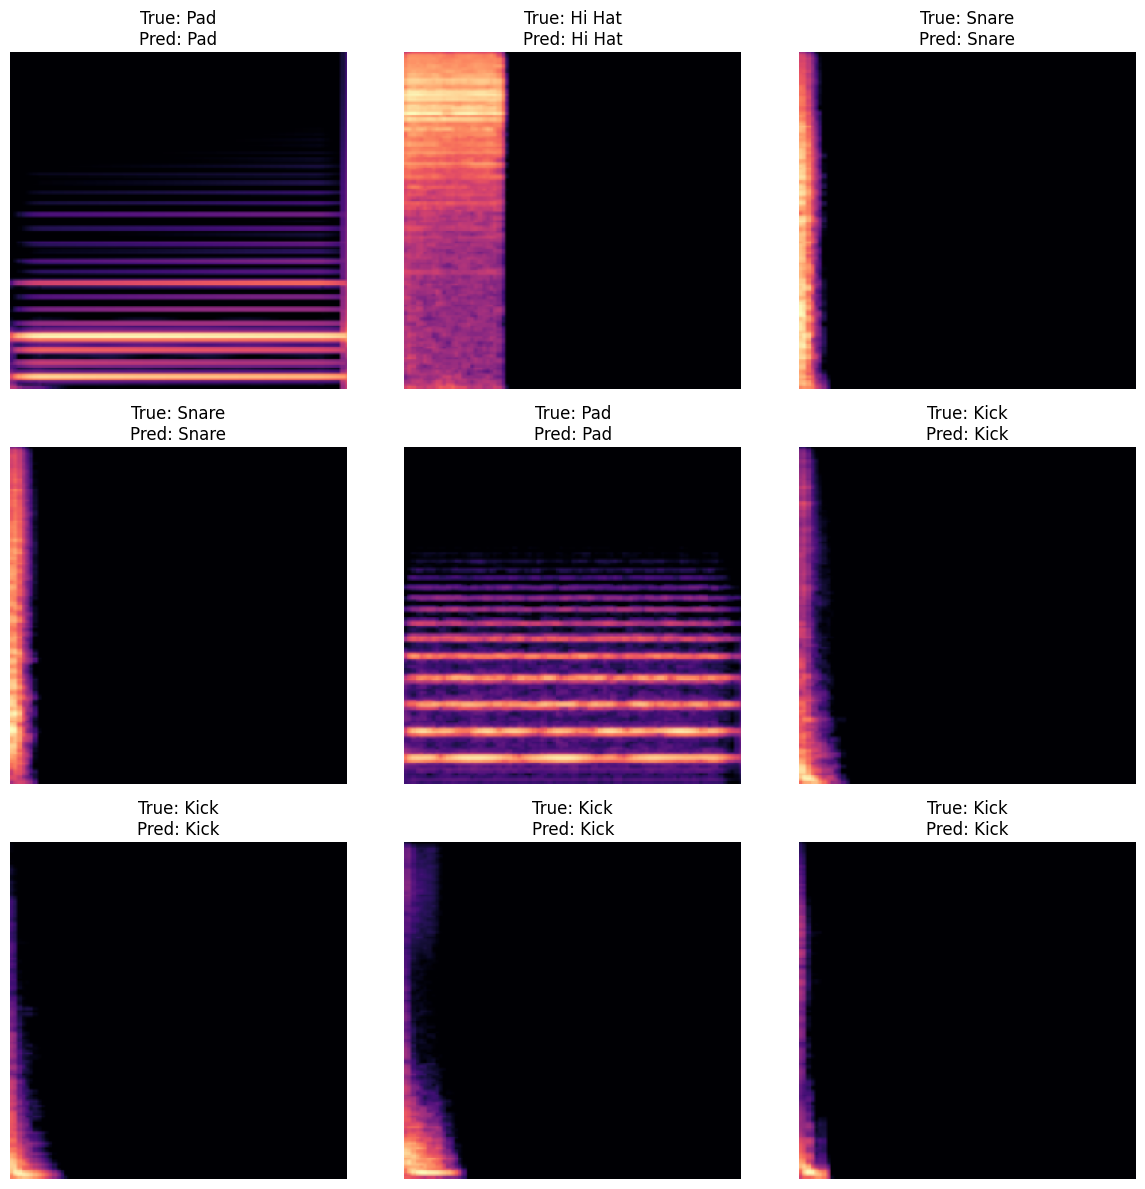

In [17]:
import random

indices = random.sample(
    range(len(test_dataset)),
    9
)

fig, axes = plt.subplots(
    3, 3,
    figsize=(12,12)
)

for ax, idx in zip(axes.flatten(), indices):

    image, label = test_dataset[idx]

    with torch.no_grad():

        output = model(
            image.unsqueeze(0).to(DEVICE)
        )

        pred = torch.argmax(
            output,
            dim=1
        ).item()

    ax.imshow(
        image.permute(1,2,0)
    )

    ax.set_title(
        f"True: {class_names[label]}\nPred: {class_names[pred]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## Error Analysis

In [18]:
misclassified = [
    i for i in range(len(all_preds))
    if all_preds[i] != all_labels[i]
]

print(f"Misclassified samples: {len(misclassified)}")

Misclassified samples: 14


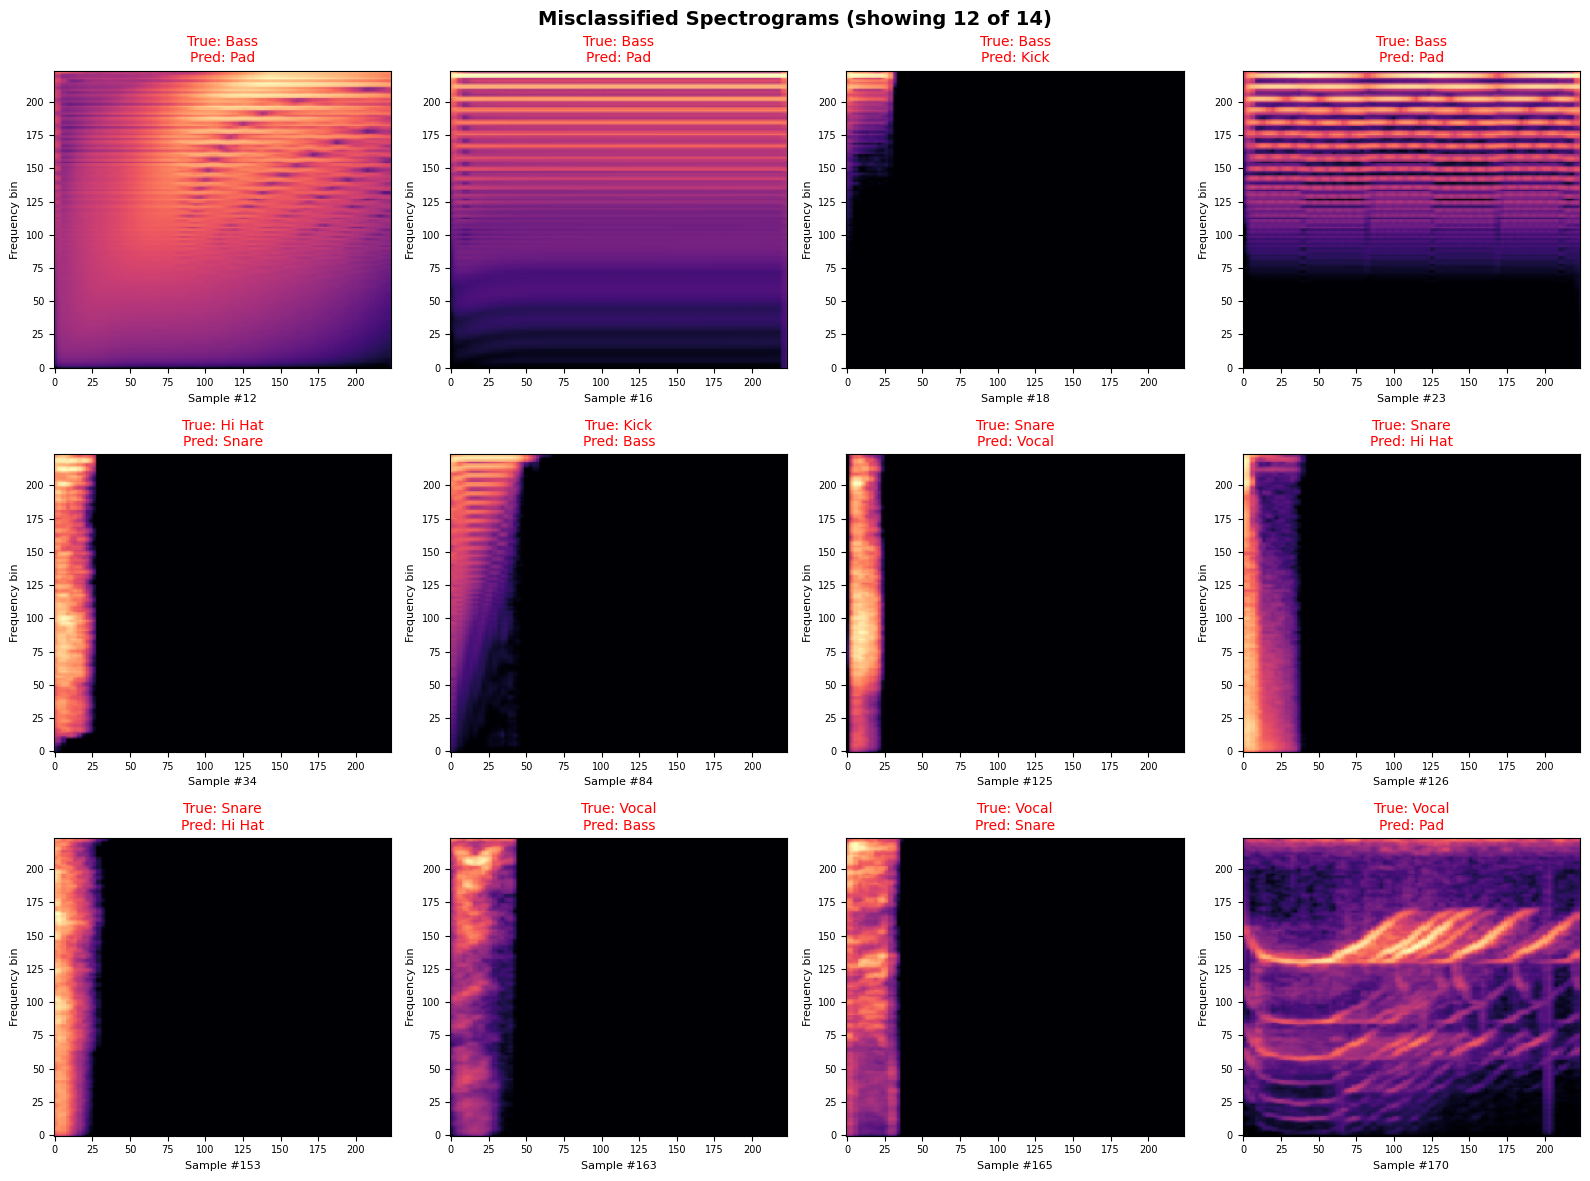

In [19]:
# Plot misclassified spectrograms
MAX_DISPLAY = 12  # cap at 12 so the grid stays readable
samples_to_show = misclassified[:MAX_DISPLAY]

ncols = 4
nrows = -(-len(samples_to_show) // ncols)  # ceiling division

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 4, nrows * 4)
)

axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax, idx in zip(axes_flat, samples_to_show):

    image, label = test_dataset[idx]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(DEVICE))
        pred = torch.argmax(output, dim=1).item()

    img_np = image.permute(1, 2, 0).cpu().numpy()
    if img_np.shape[-1] == 1:
        img_np = img_np.squeeze(-1)
        ax.imshow(img_np, origin='lower', aspect='auto', cmap='magma')
    else:
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        ax.imshow(img_np, origin='lower', aspect='auto')

    ax.set_title(
        f"True: {class_names[label]}\nPred: {class_names[pred]}",
        color='red', fontsize=10
    )
    ax.set_xlabel(f"Sample #{idx}", fontsize=8)
    ax.set_ylabel("Frequency bin", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes_flat[len(samples_to_show):]:
    ax.set_visible(False)

fig.suptitle(
    f"Misclassified Spectrograms (showing {len(samples_to_show)} of {len(misclassified)})",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Key Takeaways

- **Overall test accuracy: 92.47%** — The model generalises well to unseen data,
  finishing slightly below the validation accuracy of 95.6% seen during training.

- **Strongest classes:**  Kick, Pad, and Snare achieved the highest F1-scores,
  suggesting their spectrograms have distinctive, learnable frequency patterns.

- **Hardest classes:** Bass and Pad showed the most confusion with each
  other, likely because their frequency content or temporal structure overlaps.  They both share a similar striped formation of frequency on the spectrogram, although the stripes vary in thickness between the two classes.

- **Error analysis:** The misclassified spectrograms predominantly involve shorter samples or samples with the striped frequency pattern that the Bass and Pad classes both possess — pointing to data augmentation and accumulating more data as the most promising next step.